## PCA y clasificación de subtipos de cáncer de mama

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [48]:
data = pd.read_csv(
    r"C:\Users\alons\Downloads\Breast_GSE45827.csv\Breast_GSE45827.csv"
)

data.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [49]:
# Separar variables (X) de la etiqueta/subtipo de cáncer (y)
# Drop de 'samples' porque es un ID y 'type' porque es el target
y = data["type"]
X = data.drop(columns=["samples", "type"])
print(X.shape)
print(y.value_counts())

(151, 54675)
type
basal        41
HER          30
luminal_B    30
luminal_A    29
cell_line    14
normal        7
Name: count, dtype: int64


In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, range(len(le.classes_)))))

{'HER': 0, 'basal': 1, 'cell_line': 2, 'luminal_A': 3, 'luminal_B': 4, 'normal': 5}


In [51]:
from sklearn.preprocessing import StandardScaler

# Escalamiento de datos
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [52]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

exp_var = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_)+1),
    "Variance": pca.explained_variance_ratio_
})

exp_var["Cumulative"] = exp_var["Variance"].cumsum()

exp_var.head()

,PC,Variance,Cumulative
0,1,0.111808,0.111808
1,2,0.101860,0.213667
2,3,0.052229,0.265896
3,4,0.033840,0.299736
4,5,0.032932,0.332668


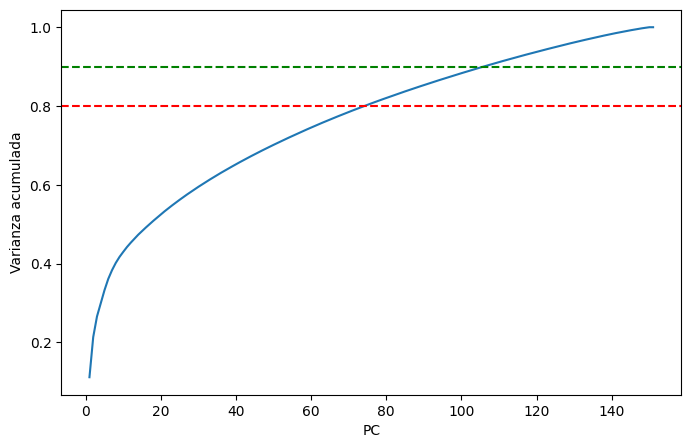

In [53]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=exp_var,
    x="PC",
    y="Cumulative"
)

plt.axhline(0.80, color="red", linestyle="--")
plt.axhline(0.90, color="green", linestyle="--")

plt.ylabel("Varianza acumulada")
plt.show()

In [54]:
n_components = (
    exp_var[exp_var["Cumulative"] <= 0.90]
    .shape[0]
)

print(n_components)

105


In [55]:
pca = PCA(n_components=105)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(151, 105)


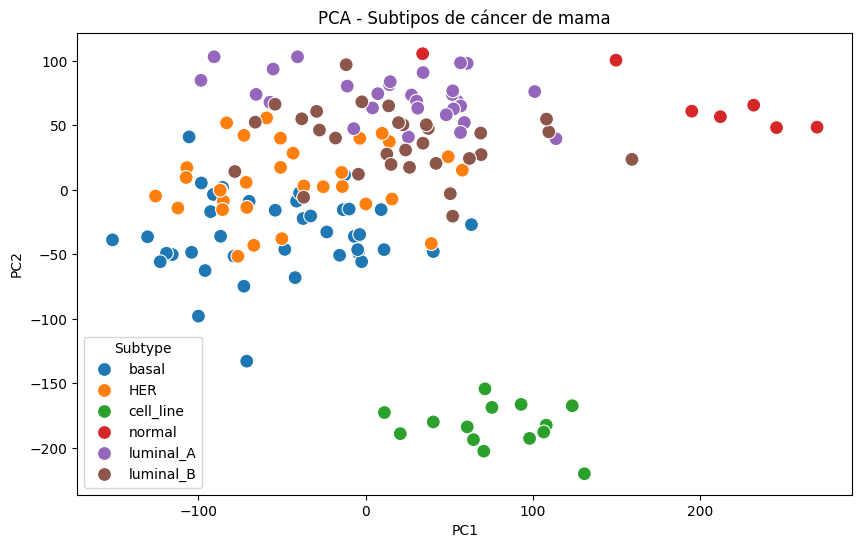

In [56]:
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

pca_df["Subtype"] = y.values

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Subtype",
    s=100
)

plt.title("PCA - Subtipos de cáncer de mama")
plt.show()

In [57]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(105)]
)

loadings["PC1"].abs().sort_values(
    ascending=False
).head(10)

206849_at      0.010768
1560451_at     0.010630
216102_at      0.010621
216114_at      0.010514
234797_at      0.010511
244890_at      0.010480
225952_at      0.010459
239592_at      0.010419
220114_s_at    0.010412
1570281_at     0.010385
Name: PC1, dtype: float64

In [58]:
loadings["PC2"].abs().sort_values(
    ascending=False
).head(10)

200795_at      0.012263
241777_x_at    0.012084
222358_x_at    0.012062
222282_at      0.012003
232347_x_at    0.011989
232597_x_at    0.011975
236494_x_at    0.011932
217679_x_at    0.011917
232266_x_at    0.011880
236153_at      0.011867
Name: PC2, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Separación en entrenamiento y prueba (Mantenemos un random_state constante)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs"],
    "max_iter": [5000]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy CV:", grid.best_score_)

Mejores parámetros: {'C': 0.01, 'max_iter': 5000, 'solver': 'lbfgs'}
Mejor accuracy CV: 0.9238095238095237


In [60]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

         HER       0.90      1.00      0.95         9
       basal       1.00      0.92      0.96        13
   cell_line       1.00      1.00      1.00         4
   luminal_A       0.78      0.78      0.78         9
   luminal_B       0.80      0.89      0.84         9
      normal       1.00      0.50      0.67         2

    accuracy                           0.89        46
   macro avg       0.91      0.85      0.87        46
weighted avg       0.90      0.89      0.89        46



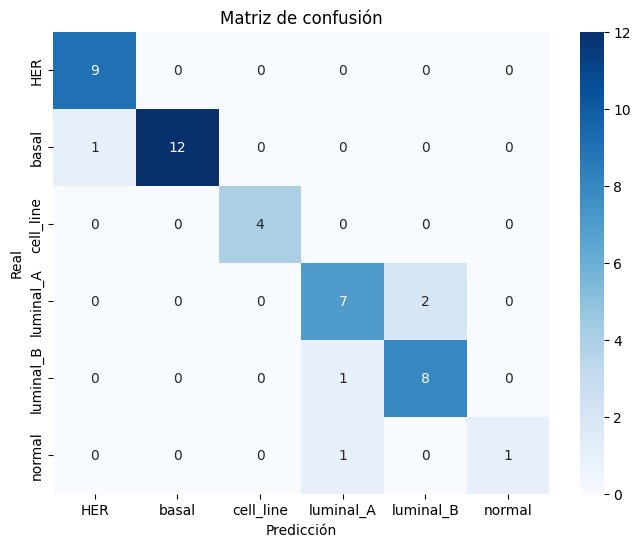

In [61]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

In [62]:
# Se aplicó PCA al dataset CuMiDa con el objetivo de reducir la dimensionalidad de los datos de expresión génica. Se seleccionaron 105 componentes principales, los cuales explican aproximadamente el 90% de la varianza acumulada, permitiendo conservar la mayor parte de la información original.

# La visualización de los dos primeros componentes mostró una separación parcial entre los distintos subtipos de cáncer de mama, evidenciando que las expresiones génicas contienen información discriminante relevante.

# Los loadings de PC1 y PC2 permitieron identificar los genes con mayor contribución a la variabilidad de los datos. Estos genes podrían estar asociados a diferencias biológicas entre los subtipos estudiados.

# Posteriormente se entrenó un modelo de Regresión Logística utilizando búsqueda de hiperparámetros mediante Grid Search. El mejor modelo obtuvo un accuracy promedio de validación cruzada de 92.38% y un accuracy de prueba cercano al 89%.

# Los resultados muestran que la combinación de PCA y Regresión Logística permite clasificar de manera efectiva los subtipos de cáncer de mama presentes en el dataset, obteniendo métricas de precisión, recall y F1-score elevadas para la mayoría de las clases.